# Targeted Promotion Incrementality Analysis

## Objective

Estimate the incremental revenue impact of a 10% targeted discount for high-LTV users using experimental and quasi-experimental methods.

This analysis includes:
- Post-period Average Treatment Effect (ATE)
- Confidence intervals
- Difference-in-Differences (DiD)
- Fixed Effects panel estimation
- Cluster-robust inference
- Model comparison and robustness checks

Additionally, heterogeneous treatment effects are explored using a causal forest model to assess variation in response across users.

## Key Findings

- Post-period ATE suggests a positive revenue lift of **+$28.50 per user** (95% CI: [$23.90, $33.11])

- Difference-in-differences estimates vary substantially across specifications:
  - Clustered DiD: **+$8.74**
  - User fixed effects: **+$4.53**
  - Two-way fixed effects: **-$1.58**
  - Weighted DiD: **+$8.61** (95% CI: [$7.76, $9.47])

- Treatment effect estimates are **highly sensitive to model specification**, ranging from positive to negative.

- ROI estimates vary substantially depending on identification strategy. Using the experimental ATE suggests positive revenue lift, while panel-based estimates imply negative returns. Given the randomized design, the ATE-based estimate is the more credible benchmark.

- The randomized design provides a credible causal estimate via the post-period ATE. Divergence across Difference-in-Differences specifications suggests sensitivity to modeling assumptions and potential pre-treatment differences, so panel-based estimates are treated as robustness checks rather than primary causal estimates.

## Experiment Design

**Population**
- High-LTV users identified prior to experiment launch
- 55,102 eligible users included in post-period analysis
- Randomized at the user level

**Treatment**
- 10% targeted discount offered to treatment group
- Control group received no promotional discount

**Randomization**
- User-level assignment with randomized treatment exposure (validated via pre-period balance checks)

**Outcome Metric**
- Revenue per user (post-period)
- Weekly revenue for panel-based DiD analysis

**Time Window**
- 6-week pre-period (baseline)
- 6-week post-period (treatment exposure)

**Identification Strategy**
- Treatment effects are first estimated using post-period ATE.
- Difference-in-Differences and fixed-effects panel models are then used as robustness checks to control for time trends and user-level heterogeneity.
- Because event-study diagnostics show modest pre-treatment differences that may be sensitive to the chosen reference period, panel-based estimates are used as robustness checks, while the randomized ATE remains the primary causal estimate.

## Assumptions & Validity

- Post-period comparisons assume treated and control users are comparable within the eligible high-LTV population.
- Event-study diagnostics show modest pre-treatment differences relative to the chosen baseline period (t = -1). These patterns suggest caution, though they may be sensitive to the normalization choice.
- Cluster-robust standard errors account for within-user correlation over time.
- User and time fixed effects reduce bias from time-invariant user heterogeneity and common time shocks, but do not fully resolve concerns around pre-treatment differences.
- Sensitivity across specifications suggests remaining model dependence.

## 1. Environment & Setup

Load dependencies and establish a secure database connection using environment variables.

In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import psycopg2

# Load environment variables from .env
load_dotenv()

conn = psycopg2.connect(
    dbname=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
)


In [2]:
def coef_line(model, term="interaction"):
    b = model.params[term]
    se = model.bse[term]
    p = model.pvalues[term]
    ci_low, ci_high = model.conf_int().loc[term]
    return {
        "coef": round(b, 2),
        "se": round(se, 3),
        "p": p,
        "ci_low": round(ci_low, 2),
        "ci_high": round(ci_high, 2)
    }

## 2. Post-Period Aggregated Data

Pull user-level post-period revenue summary for eligible high-LTV users.

This dataset contains:
- `user_id`
- `treatment_flag`
- `post_revenue`

Used to estimate the primary post-period Average Treatment Effect (ATE).

In [3]:
query = """
select *
from analysis.post_user_summary
"""

df = pd.read_sql(query, conn)

df.head()

C:\Users\trist\AppData\Local\Temp\ipykernel_30864\960220042.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,user_id,treatment_flag,post_revenue
0,2,1,318.3516
1,10,1,662.5908
2,11,0,64.0100
3,17,0,327.7300
4,19,0,442.8600


In [4]:
len(df)

55102

**Sample Size:** 55,102 high-LTV users

## 3. Primary Result: Post-Period ATE

We estimate the Average Treatment Effect (ATE) using a two-sample t-test
comparing treatment and control post-period revenue.

In [5]:
import numpy as np
import pandas as pd

treat = df.loc[df["treatment_flag"] == 1, "post_revenue"]
ctrl  = df.loc[df["treatment_flag"] == 0, "post_revenue"]

treat_mean = treat.mean()
ctrl_mean  = ctrl.mean()
lift = treat_mean - ctrl_mean
pct_lift = (lift / ctrl_mean) * 100

se = np.sqrt(treat.var(ddof=1)/len(treat) + ctrl.var(ddof=1)/len(ctrl))
ci_low  = lift - 1.96 * se
ci_high = lift + 1.96 * se

results_summary = pd.DataFrame({
    "Metric": ["Control Mean (Post)", "Treatment Mean (Post)", "ATE Lift ($)", "Percent Lift (%)", "95% CI Low", "95% CI High"],
    "Value":  [ctrl_mean, treat_mean, lift, pct_lift, ci_low, ci_high]
})

results_summary["Value"] = results_summary["Value"].round(4)
results_summary

,Metric,Value
0,Control Mean (Post),349.3741
1,Treatment Mean (Post),377.8744
2,ATE Lift ($),28.5002
3,Percent Lift (%),8.1575
4,95% CI Low,23.8953
5,95% CI High,33.1052


**Interpretation:**

Post-period ATE lift: +$28.50 per user (+8.16%)

95% CI: [$23.90, $33.11] → statistically significant (CI does not include 0)

## 4. Confidence Interval Estimation

Compute standard error and 95% confidence interval for the estimated lift.

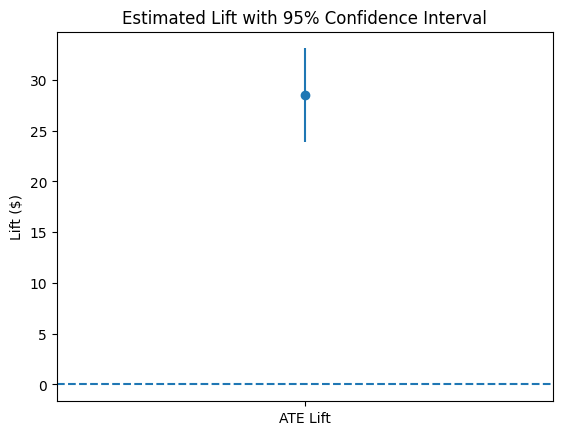

In [6]:
import matplotlib.pyplot as plt

err_low  = lift - ci_low
err_high = ci_high - lift

plt.figure()
plt.errorbar(
    x=[0],
    y=[lift],
    yerr=[[err_low], [err_high]],
    fmt="o"
);
plt.xticks([0], ["ATE Lift"])
plt.axhline(0, linestyle='--')
plt.ylabel("Lift ($)")
plt.title("Estimated Lift with 95% Confidence Interval")
plt.show()

The 95% confidence interval does not cross 0, indicating statistical significance at the 5% level.

## 5. Post-Period Revenue Comparison

Visual comparison of mean post-period revenue per user.

In [7]:
treatment = df[df["treatment_flag"] == 1]["post_revenue"]
control = df[df["treatment_flag"] == 0]["post_revenue"]

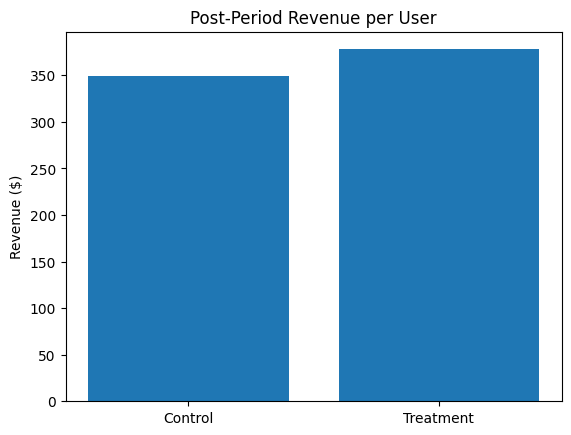

In [8]:
import matplotlib.pyplot as plt

treatment_mean = treatment.mean()
control_mean = control.mean()

plt.figure()
plt.bar(["Control", "Treatment"], [control_mean, treatment_mean])
plt.title("Post-Period Revenue per User")
plt.ylabel("Revenue ($)")
plt.show()

## 6. Panel Dataset Construction

Construct user-week panel data (pre vs post) for high-LTV users to enable Difference-in-Differences estimation.

In [9]:
query = """
select
    user_id,
    treatment_flag,
    high_ltv_flag,
    pre_post_flag,
    revenue_sim
from marts.mart_user_week_experiment_sim
where high_ltv_flag = 1
  and pre_post_flag in ('pre','post')
"""

panel_df = pd.read_sql(query, conn)

panel_df.head()

C:\Users\trist\AppData\Local\Temp\ipykernel_30864\2673839738.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  panel_df = pd.read_sql(query, conn)


,user_id,treatment_flag,high_ltv_flag,pre_post_flag,revenue_sim
0,27,0,1,pre,55.20
1,27,0,1,pre,177.01
2,27,0,1,pre,156.31
3,27,0,1,pre,140.92
4,27,0,1,pre,397.26


In [10]:
# --- Panel dataset construction (pre vs post) ---

# 1) Ensure types
panel_df["user_id"] = panel_df["user_id"].astype(int)

# 2) Create post indicator
panel_df["post"] = (panel_df["pre_post_flag"] == "post").astype(int)

# 3) Create interaction term (treatment x post)
panel_df["interaction"] = panel_df["treatment_flag"] * panel_df["post"]

# 4) FE prep: demean revenue within user
panel_df["revenue_demeaned"] = (
    panel_df["revenue_sim"] - panel_df.groupby("user_id")["revenue_sim"].transform("mean")
)

# quick sanity checks
panel_df[["user_id","treatment_flag","pre_post_flag","post","interaction","revenue_sim","revenue_demeaned"]].head()

,user_id,treatment_flag,pre_post_flag,post,interaction,revenue_sim,revenue_demeaned
0,27,0,pre,0,0,55.20,-97.435
1,27,0,pre,0,0,177.01,24.375
2,27,0,pre,0,0,156.31,3.675
3,27,0,pre,0,0,140.92,-11.715
4,27,0,pre,0,0,397.26,244.625


In [11]:
# Ensure panel data is sorted and has a numeric week index
panel_df["user_id"] = panel_df["user_id"].astype(int)
panel_df = panel_df.sort_values(["user_id"]).copy()

# Create within-user week order if week_index is missing
if "week_index" not in panel_df.columns:
    panel_df["week_index"] = panel_df.groupby("user_id").cumcount() + 1

panel_df["week_index"] = panel_df["week_index"].astype(int)
panel_df[["user_id", "treatment_flag", "pre_post_flag", "week_index", "revenue_sim"]].head()

,user_id,treatment_flag,pre_post_flag,week_index,revenue_sim
221309,2,1,pre,1,76.4400
221308,2,1,pre,2,75.6300
221311,2,1,pre,3,68.5000
221310,2,1,pre,4,83.6100
221313,2,1,post,5,80.6436


## 7.0 Event Study / Dynamic Treatment Effects

Estimate treatment effects by week to evaluate pre-treatment trends and post-treatment lift over time.

In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = panel_df.copy()

# keep only needed columns
df = df[["user_id", "treatment_flag", "pre_post_flag", "week_index", "revenue_sim"]].dropna().copy()

# types
df["user_id"] = df["user_id"].astype(str)
df["treatment_flag"] = df["treatment_flag"].astype(int)
df["week_index"] = df["week_index"].astype(int)
df["revenue_sim"] = df["revenue_sim"].astype(float)

# map pre/post strings to 0/1
df["pre_post_flag"] = (
    df["pre_post_flag"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"pre": 0, "post": 1})
)

# check that mapping worked
if df["pre_post_flag"].isna().any():
    bad_vals = panel_df.loc[df["pre_post_flag"].isna(), "pre_post_flag"].unique()
    raise ValueError(f"Unexpected values in pre_post_flag: {bad_vals}")

df["pre_post_flag"] = df["pre_post_flag"].astype(int)

print(df[["pre_post_flag"]].drop_duplicates().sort_values("pre_post_flag"))
print(sorted(df["week_index"].unique()))

        pre_post_flag
221309              0
221313              1
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


In [13]:
week_map = {
    1: -6,
    2: -5,
    3: -4,
    4: -3,
    5: -2,
    6: -1,
    7: 0,
    8: 1,
    9: 2,
    10: 3,
    11: 4,
    12: 5
}

df["event_time"] = df["week_index"].map(week_map)

print("Event weeks:", sorted(df["event_time"].unique()))
print("Last pre week:", df.loc[df["pre_post_flag"] == 0, "event_time"].max())
print("First post week:", df.loc[df["pre_post_flag"] == 1, "event_time"].min())

Event weeks: [np.int64(-6), np.int64(-5), np.int64(-4), np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Last pre week: 5
First post week: -6


In [14]:
# rebuild pre_post_flag directly from week_index
df["pre_post_flag"] = np.where(df["week_index"] <= 6, 0, 1)

# re-check
print("Event weeks:", sorted(df["event_time"].unique()))
print("Last pre week:", df.loc[df["pre_post_flag"] == 0, "event_time"].max())
print("First post week:", df.loc[df["pre_post_flag"] == 1, "event_time"].min())

Event weeks: [np.int64(-6), np.int64(-5), np.int64(-4), np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Last pre week: -1
First post week: 0


In [15]:
event_weeks = sorted(df["event_time"].unique())
reference_week = -1

interaction_cols = []

for w in event_weeks:
    if w == reference_week:
        continue
    col_name = f"event_{w}"
    df[col_name] = ((df["event_time"] == w) & (df["treatment_flag"] == 1)).astype(int)
    interaction_cols.append(col_name)

print(interaction_cols)
print(df[interaction_cols].head())

['event_-6', 'event_-5', 'event_-4', 'event_-3', 'event_-2', 'event_0', 'event_1', 'event_2', 'event_3', 'event_4', 'event_5']
        event_-6  event_-5  event_-4  event_-3  event_-2  event_0  event_1  \
221309         1         0         0         0         0        0        0   
221308         0         1         0         0         0        0        0   
221311         0         0         1         0         0        0        0   
221310         0         0         0         1         0        0        0   
221313         0         0         0         0         1        0        0   

        event_2  event_3  event_4  event_5  
221309        0        0        0        0  
221308        0        0        0        0  
221311        0        0        0        0  
221310        0        0        0        0  
221313        0        0        0        0  


In [16]:
def twfe_residualize(df, col, entity_col="user_id", time_col="event_time"):
    x = df[col].astype(float)
    entity_mean = df.groupby(entity_col)[col].transform("mean")
    time_mean = df.groupby(time_col)[col].transform("mean")
    overall_mean = x.mean()
    return x - entity_mean - time_mean + overall_mean

# residualized outcome
y_tilde = twfe_residualize(df, "revenue_sim")

# residualized interaction regressors
X_tilde = pd.DataFrame(index=df.index)

for col in interaction_cols:
    X_tilde[col] = twfe_residualize(df, col)

# run clustered OLS
event_model = sm.OLS(y_tilde, X_tilde).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["user_id"]}
)

print(event_model.summary())

                                 OLS Regression Results                                
Dep. Variable:            revenue_sim   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):              0.000
Method:                 Least Squares   F-statistic:                              3.296
Date:                Mon, 27 Apr 2026   Prob (F-statistic):                    0.000154
Time:                        17:43:49   Log-Likelihood:                     -2.3661e+06
No. Observations:              440501   AIC:                                  4.732e+06
Df Residuals:                  440490   BIC:                                  4.732e+06
Df Model:                          11                                                  
Covariance Type:              cluster                                                  
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

In [17]:
event_results = pd.DataFrame({
    "term": event_model.params.index,
    "coef": event_model.params.values,
    "se": event_model.bse.values
})

# extract numeric week
event_results["event_time"] = (
    event_results["term"]
    .str.replace("event_", "", regex=False)
    .astype(int)
)

# confidence intervals
event_results["ci_low"] = event_results["coef"] - 1.96 * event_results["se"]
event_results["ci_high"] = event_results["coef"] + 1.96 * event_results["se"]

# add reference period (-1)
ref_row = pd.DataFrame({
    "term": ["reference"],
    "coef": [0.0],
    "se": [0.0],
    "event_time": [-1],
    "ci_low": [0.0],
    "ci_high": [0.0]
})

event_results = pd.concat([event_results, ref_row], ignore_index=True)
event_results = event_results.sort_values("event_time").reset_index(drop=True)

print(event_results)

         term      coef        se  event_time    ci_low   ci_high
0    event_-6  1.924101  0.694233          -6  0.563404  3.284799
1    event_-5  2.038739  0.696548          -5  0.673505  3.403974
2    event_-4  2.101166  0.692302          -4  0.744254  3.458079
3    event_-3  1.135708  0.701985          -3 -0.240182  2.511599
4    event_-2  1.209085  0.725442          -2 -0.212783  2.630952
5   reference  0.000000  0.000000          -1  0.000000  0.000000
6     event_0 -0.645675  0.790270           0 -2.194604  0.903255
7     event_1 -0.198008  0.849511           1 -1.863049  1.467032
8     event_2  0.236961  0.935004           2 -1.595647  2.069568
9     event_3  0.026507  1.068042           3 -2.066856  2.119870
10    event_4  1.145314  1.334484           4 -1.470274  3.760902
11    event_5  0.926355  1.905504           5 -2.808433  4.661143


In [18]:
from pathlib import Path

out_path = Path("../data/processed/event_study.csv")
event_results.to_csv(out_path, index=False)
print(out_path.resolve())

C:\Users\trist\ab-promo-incrementality\data\processed\event_study.csv


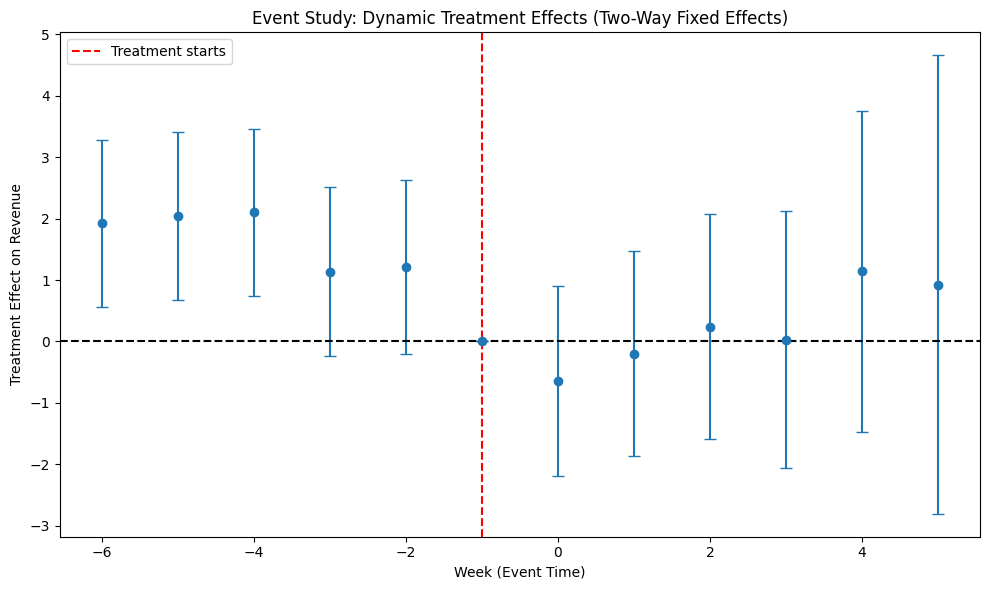

In [19]:
plt.figure(figsize=(10, 6))

plt.errorbar(
    event_results["event_time"],
    event_results["coef"],
    yerr=1.96 * event_results["se"],
    fmt="o",
    capsize=4
)

plt.axhline(0, linestyle="--", color="black")
plt.axvline(-1, linestyle="--", color="red", label="Treatment starts")

plt.xlabel("Week (Event Time)")
plt.ylabel("Treatment Effect on Revenue")
plt.title("Event Study: Dynamic Treatment Effects (Two-Way Fixed Effects)")

plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

The event study shows modest pre-treatment differences relative to the chosen baseline period (t = -1). Because event study coefficients are measured relative to a reference period, these patterns may be sensitive to the normalization choice.

As a result, while the results suggest some caution in interpreting Difference-in-Differences estimates, they do not provide definitive evidence of a strong violation of the parallel trends assumption.

In [20]:
pre_terms = [c for c in interaction_cols if int(c.split("_")[1]) < 0]

from statsmodels.stats.contrast import ContrastResults

R = np.zeros((len(pre_terms), len(event_model.params)))

for i, term in enumerate(pre_terms):
    idx = list(event_model.params.index).index(term)
    R[i, idx] = 1

f_test = event_model.f_test(R)
print(f_test)

<F test: F=2.6904088462221147, p=0.01950048176240322, df_denom=6.19e+04, df_num=5>


A joint test rejects that all pre-treatment coefficients are zero relative to the omitted baseline period (t = -1). This suggests caution when interpreting DiD estimates, but does not by itself prove a severe parallel trends violation because event-study coefficients are sensitive to the chosen reference period.

## 7.1 Addressing Selection Bias (Propensity Score Weighting)

In [21]:
# build user-level pre-treatment features
ps_df = (
    panel_df[panel_df["pre_post_flag"] == "pre"]
    .groupby("user_id")
    .agg(
        baseline_revenue=("revenue_sim", "mean"),
        pre_rev_std=("revenue_sim", "std"),
        pre_weeks=("revenue_sim", "count"),
        treatment_flag=("treatment_flag", "max")
    )
    .reset_index()
)

ps_df["pre_rev_std"] = ps_df["pre_rev_std"].fillna(0)

In [22]:
from sklearn.linear_model import LogisticRegression

X_ps = ps_df[["baseline_revenue", "pre_rev_std", "pre_weeks"]]
T_ps = ps_df["treatment_flag"]

logit = LogisticRegression(max_iter=1000)
logit.fit(X_ps, T_ps)

ps_df["propensity_score"] = logit.predict_proba(X_ps)[:, 1]

In [23]:
# inverse probability weights
ps_df["weight"] = (
    ps_df["treatment_flag"] / ps_df["propensity_score"] +
    (1 - ps_df["treatment_flag"]) / (1 - ps_df["propensity_score"])
)

In [24]:
panel_w = panel_df.merge(
    ps_df[["user_id", "weight"]],
    on="user_id",
    how="left"
)

In [25]:
import statsmodels.api as sm

X_w = panel_w[["treatment_flag", "post", "interaction"]]
X_w = sm.add_constant(X_w)
y_w = panel_w["revenue_sim"]
w = panel_w["weight"]

did_weighted = sm.WLS(y_w, X_w, weights=w).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel_w["user_id"]}
)

print(did_weighted.summary())

                            WLS Regression Results                            
Dep. Variable:            revenue_sim   R-squared:                       0.003
Model:                            WLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     440.8
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          2.27e-283
Time:                        17:43:50   Log-Likelihood:            -2.5092e+06
No. Observations:              440501   AIC:                         5.018e+06
Df Residuals:                  440497   BIC:                         5.018e+06
Df Model:                           3                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            116.2850      0.307    378.

In [26]:
coef = did_weighted.params["interaction"]
se = did_weighted.bse["interaction"]

ci_low = coef - 1.96 * se
ci_high = coef + 1.96 * se

print(f"Weighted DiD lift: ${coef:.2f} (95% CI: ${ci_low:.2f}, ${ci_high:.2f})")

Weighted DiD lift: $8.61 (95% CI: $7.76, $9.47)


After reweighting users to better balance pre-treatment characteristics, the estimated treatment effect increases to approximately $8.61 per user (95% CI: $7.76 to $9.47). This suggests that model specification and weighting assumptions materially impact the estimated effect, highlighting sensitivity to identification strategy.

However, this estimate contrasts sharply with the two-way fixed effects result, which shows no positive impact. The divergence across methods indicates that treatment effect estimates are highly sensitive to modeling assumptions, and reinforces the need for careful validation of identification strategies.

## 7.2 Clustered DiD

In [27]:
import statsmodels.api as sm

X_did = panel_df[["treatment_flag", "post", "interaction"]]
X_did = sm.add_constant(X_did)
y_did = panel_df["revenue_sim"]

did_cluster = sm.OLS(y_did, X_did).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel_df["user_id"]}
)

In [28]:
did_res = coef_line(did_cluster)
print(
    f"Clustered DiD weekly lift (interaction): ${did_res['coef']:.2f} "
    f"(95% CI: ${did_res['ci_low']:.2f}, ${did_res['ci_high']:.2f})"
)

Clustered DiD weekly lift (interaction): $8.74 (95% CI: $7.90, $9.59)


### Interpretation

The clustered DiD model estimates a positive and statistically significant treatment effect of $8.74 per week.

This represents the baseline difference-in-differences estimate, comparing changes in revenue for treated users relative to control users from the pre to post period.

However, this specification does not control for user-level heterogeneity or time effects, so the estimate may be biased if treated and control users differ systematically.

## 7.3  User Fixed Effects DiD
To control for time-invariant user heterogeneity, we estimate a fixed-effects DiD model using within-user demeaning.

In [29]:
X_fe = panel_df[["post", "interaction"]]
X_fe = sm.add_constant(X_fe)
y_fe = panel_df["revenue_demeaned"]

fe_cluster = sm.OLS(y_fe, X_fe).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel_df["user_id"]}
)

In [30]:
fe_res = coef_line(fe_cluster)
print(
    f"Fixed Effects DiD weekly lift (interaction): ${fe_res['coef']:.2f} "
    f"(95% CI: ${fe_res['ci_low']:.2f}, ${fe_res['ci_high']:.2f})"
)

Fixed Effects DiD weekly lift (interaction): $4.53 (95% CI: $4.13, $4.93)


**Interpretation:**  
With user fixed effects, the incremental lift remains positive (~$4.53/week), indicating some user-level heterogeneity was previously contributing to estimated lift.


## 7.4 Two-Way Fixed Effects (User + Time)

In [31]:
# create DiD interaction (if not already)
df["did"] = df["treatment_flag"] * df["pre_post_flag"]

# residualize (same function from event study)
y_twfe = twfe_residualize(df, "revenue_sim")
did_twfe = twfe_residualize(df, "did")

X_twfe = pd.DataFrame({"did": did_twfe}, index=df.index)

# run model
twfe_model = sm.OLS(y_twfe, X_twfe).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["user_id"]}
)

# extract
twfe_coef = twfe_model.params["did"]
twfe_se = twfe_model.bse["did"]
twfe_ci_low = twfe_coef - 1.96 * twfe_se
twfe_ci_high = twfe_coef + 1.96 * twfe_se

print(f"Two-Way FE DiD weekly lift: ${twfe_coef:.2f} (95% CI: ${twfe_ci_low:.2f}, ${twfe_ci_high:.2f})")

Two-Way FE DiD weekly lift: $-1.58 (95% CI: $-2.26, $-0.89)


### Interpretation

The two-way fixed effects model controls for both user fixed effects and week fixed effects.

This accounts for time-invariant differences across users as well as common shocks across time, providing a more robust panel-data estimate.

However, the event study shows modest pre-treatment differences relative to the omitted baseline period, so this estimate should be interpreted with caution rather than as the primary causal estimate.

## 7.5 Model Comparison

In [32]:
results_table = pd.DataFrame({
    "Model": ["Naive DiD", "User FE DiD", "TWFE DiD", "Weighted DiD"],
    "Lift ($)": [8.74, 4.53, -1.58, coef],
    "95% CI Lower": [np.nan, np.nan, np.nan, ci_low],
    "95% CI Upper": [np.nan, np.nan, np.nan, ci_high],
})

results_table

,Model,Lift ($),95% CI Lower,95% CI Upper
0,Naive DiD,8.740000,NaN,NaN
1,User FE DiD,4.530000,NaN,NaN
2,TWFE DiD,-1.580000,NaN,NaN
3,Weighted DiD,8.614741,7.75529,9.474192


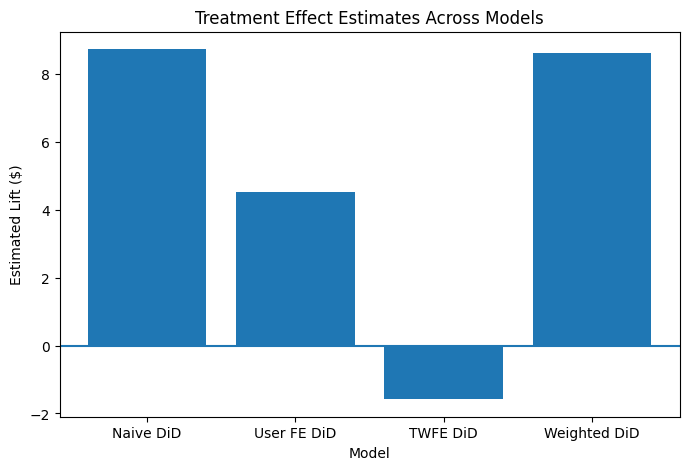

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_table["Model"], results_table["Lift ($)"])

plt.axhline(0)  # baseline

plt.title("Treatment Effect Estimates Across Models")
plt.ylabel("Estimated Lift ($)")
plt.xlabel("Model")

plt.show()

### Interpretation

Treatment effect estimates vary substantially across model specifications, ranging from positive to negative. While simpler models suggest a positive impact of the promotion, more restrictive panel specifications such as two-way fixed effects produce much smaller estimates.

This divergence suggests that estimates are sensitive to modeling choices and to pre-treatment differences between treated and control users. The event study shows modest pre-treatment differences relative to the omitted baseline period (t = -1), so the evidence should be interpreted cautiously rather than as definitive proof of a severe parallel trends violation.

The weighted DiD model partially recovers a positive estimate by rebalancing observable characteristics, but it does not fully address potential differences in underlying time trends.

Overall, this instability highlights the importance of experimental design and reinforces that the randomized post-period ATE provides the most reliable estimate of average causal impact in this setting.

## 7.6 Synthetic Control Robustness Check

To further assess whether pre-treatment differences affect the panel estimates, I implement a synthetic control robustness check. The goal is to construct a weighted combination of control-group cohorts that more closely matches the treated group’s pre-treatment revenue trajectory.

This approach provides an additional comparison group that is better aligned with treated users before the discount begins.

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Use panel dataframe
sc_df = df.copy()

# Keep needed columns
sc_df = sc_df[[
    "user_id",
    "treatment_flag",
    "event_time",
    "revenue_sim"
]].copy()

# Build user-level baseline revenue from pre-period
baseline = (
    sc_df[sc_df["event_time"] < 0]
    .groupby("user_id")["revenue_sim"]
    .mean()
    .reset_index(name="baseline_revenue")
)

sc_df = sc_df.merge(baseline, on="user_id", how="left")

# Create control cohorts by baseline revenue
control_users = sc_df[sc_df["treatment_flag"] == 0][["user_id", "baseline_revenue"]].drop_duplicates()

control_users["donor_bin"] = pd.qcut(
    control_users["baseline_revenue"],
    q=10,
    labels=False,
    duplicates="drop"
)

sc_df = sc_df.merge(control_users[["user_id", "donor_bin"]], on="user_id", how="left")

# Treated group average revenue by event time
treated_series = (
    sc_df[sc_df["treatment_flag"] == 1]
    .groupby("event_time")["revenue_sim"]
    .mean()
    .sort_index()
)

# Control donor cohort average revenue by event time
donor_panel = (
    sc_df[sc_df["treatment_flag"] == 0]
    .groupby(["event_time", "donor_bin"])["revenue_sim"]
    .mean()
    .unstack()
    .sort_index()
)

# Align time periods
common_times = treated_series.index.intersection(donor_panel.index)
treated_series = treated_series.loc[common_times]
donor_panel = donor_panel.loc[common_times]

# Pre-treatment periods only
pre_periods = treated_series.index[treated_series.index < 0]

Y_treated_pre = treated_series.loc[pre_periods].values
Y_donors_pre = donor_panel.loc[pre_periods].values

n_donors = Y_donors_pre.shape[1]

# Objective: choose donor weights to match treated pre-period trend
def objective(w):
    synthetic_pre = Y_donors_pre @ w
    return np.mean((Y_treated_pre - synthetic_pre) ** 2)

constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
bounds = [(0, 1)] * n_donors
initial_weights = np.ones(n_donors) / n_donors

result = minimize(
    objective,
    initial_weights,
    bounds=bounds,
    constraints=constraints,
    method="SLSQP"
)

weights = result.x

# Build synthetic control series
synthetic_series = pd.Series(
    donor_panel.values @ weights,
    index=donor_panel.index,
    name="synthetic_control"
)

# Estimate average post-period effect
post_periods = treated_series.index[treated_series.index >= 0]

synthetic_effect = (
    treated_series.loc[post_periods] - synthetic_series.loc[post_periods]
).mean()

pre_fit_rmse = np.sqrt(
    np.mean((treated_series.loc[pre_periods] - synthetic_series.loc[pre_periods]) ** 2)
)

print("Synthetic Control Avg Post-Period Effect:", synthetic_effect)
print("Pre-period fit RMSE:", pre_fit_rmse)

Synthetic Control Avg Post-Period Effect: 2.1143335741864084
Pre-period fit RMSE: 2.3838778378707732


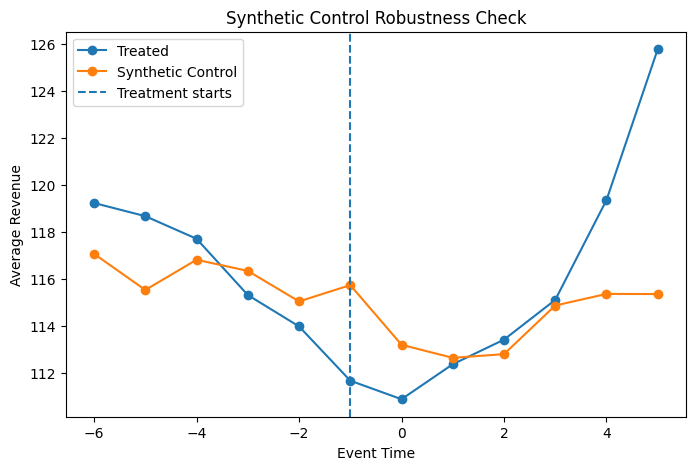

In [58]:
plt.figure(figsize=(8, 5))

plt.plot(treated_series.index, treated_series.values, marker="o", label="Treated")
plt.plot(synthetic_series.index, synthetic_series.values, marker="o", label="Synthetic Control")

plt.axvline(-1, linestyle="--", label="Treatment starts")
plt.title("Synthetic Control Robustness Check")
plt.xlabel("Event Time")
plt.ylabel("Average Revenue")
plt.legend()
plt.show()

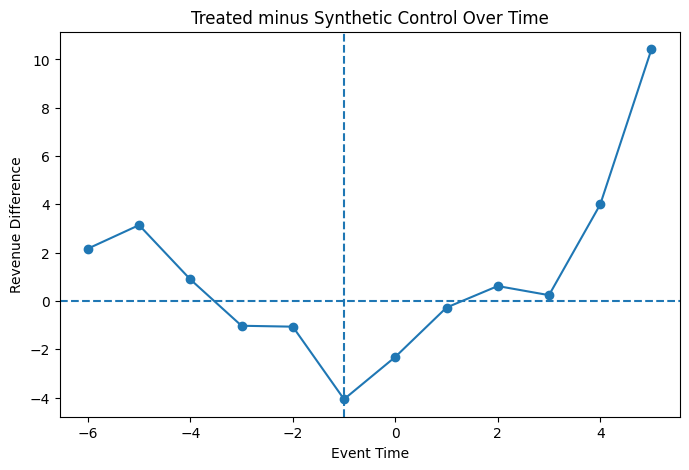

In [59]:
sc_effect_series = treated_series - synthetic_series

plt.figure(figsize=(8, 5))
plt.plot(sc_effect_series.index, sc_effect_series.values, marker="o")
plt.axhline(0, linestyle="--")
plt.axvline(-1, linestyle="--")
plt.title("Treated minus Synthetic Control Over Time")
plt.xlabel("Event Time")
plt.ylabel("Revenue Difference")
plt.show()

### Interpretation

The synthetic control robustness check constructs a weighted combination of control cohorts that more closely matches the treated group’s pre-treatment revenue trajectory.

The average post-period gap between treated users and the synthetic control provides an additional robustness estimate of the promotion’s effect after accounting for pre-treatment differences in observed spending patterns.

In this robustness check, the synthetic-control estimate is approximately **+$2.11 per user**, with a pre-period fit RMSE of **2.38**.

This estimate should be interpreted as a robustness check rather than the primary result. The randomized post-period ATE remains the main causal estimate, while the synthetic control analysis helps assess whether conclusions are sensitive to pre-treatment trend differences.

In [60]:
synthetic_results = pd.DataFrame({
    "event_time": treated_series.index,
    "treated": treated_series.values,
    "synthetic_control": synthetic_series.values,
    "effect": sc_effect_series.values
})

synthetic_results.to_csv("../data/processed/synthetic_control.csv", index=False)

## 7.7 Business Impact: Revenue vs Discount Cost

In [34]:
# assume 10% discount
discount_rate = 0.10

# avg treated post revenue
treated_post = panel_df.loc[
    (panel_df["treatment_flag"] == 1) & (panel_df["post"] == 1),
    "revenue_sim"
].mean()

discount_cost = treated_post * discount_rate

# ATE (clean, experiment-based)
ate_lift = (
    panel_df.loc[(panel_df["treatment_flag"] == 1) & (panel_df["post"] == 1), "revenue_sim"].mean()
    - panel_df.loc[(panel_df["treatment_flag"] == 0) & (panel_df["post"] == 1), "revenue_sim"].mean()
)

print("Estimated lift (ATE):", ate_lift)
print("Estimated discount cost:", discount_cost)
print("Net impact:", ate_lift - discount_cost)

Estimated lift (ATE): 8.498224308256908
Estimated discount cost: 11.491530063040546
Net impact: -2.9933057547836377


### Interpretation

The experimental ATE suggests a positive incremental revenue effect, but the average revenue lift remains smaller than the estimated discount cost under a blanket 10% offer. This suggests profitability would likely require more efficient targeting or a lower discount rate.

In [35]:
num_treated = panel_df.loc[panel_df["treatment_flag"] == 1, "user_id"].nunique()

total_impact = (ate_lift - discount_cost) * num_treated

print("Total campaign impact:", total_impact)

Total campaign impact: -92409.33526168046


## 8. Heterogeneous Treatment Effects (Quartiles)

Estimate treatment lift by baseline spend quartile to evaluate whether promotion impact differs across user segments.

In [36]:
print(df.columns.tolist())
print(hte_df.columns.tolist() if "hte_df" in globals() else "hte_df not created yet")

['user_id', 'treatment_flag', 'pre_post_flag', 'week_index', 'revenue_sim', 'event_time', 'event_-6', 'event_-5', 'event_-4', 'event_-3', 'event_-2', 'event_0', 'event_1', 'event_2', 'event_3', 'event_4', 'event_5', 'did']
hte_df not created yet


In [37]:
# 8. Heterogeneous Treatment Effects (Quartiles)

# rebuild post-period user dataset fresh so nothing overwritten earlier breaks this section
query_post = """
select *
from analysis.post_user_summary
"""

post_df = pd.read_sql(query_post, conn)

query_pre = """
select
    user_id,
    treatment_flag,
    pre_revenue
from (
    select
        user_id,
        treatment_flag,
        sum(revenue_sim) as pre_revenue
    from marts.mart_user_week_experiment_sim
    where high_ltv_flag = 1
      and pre_post_flag = 'pre'
    group by 1,2
) t
"""

pre_df = pd.read_sql(query_pre, conn)

# align dtypes
post_df["user_id"] = post_df["user_id"].astype(int)
pre_df["user_id"] = pre_df["user_id"].astype(int)
post_df["treatment_flag"] = post_df["treatment_flag"].astype(int)
pre_df["treatment_flag"] = pre_df["treatment_flag"].astype(int)

# merge
hte_df = post_df.merge(
    pre_df,
    on=["user_id", "treatment_flag"],
    how="inner"
).copy()

print(hte_df.columns.tolist())
print(hte_df.head())

# quartiles
hte_df["baseline_quartile"] = pd.qcut(
    hte_df["pre_revenue"],
    4,
    labels=["Q1 Low", "Q2", "Q3", "Q4 High"]
)

# summary
hte_summary = (
    hte_df.groupby(["baseline_quartile", "treatment_flag"])["post_revenue"]
    .mean()
    .unstack()
    .reset_index()
)

hte_summary.columns = ["baseline_quartile", "control_mean", "treatment_mean"]
hte_summary["lift"] = hte_summary["treatment_mean"] - hte_summary["control_mean"]
hte_summary["pct_lift"] = hte_summary["lift"] / hte_summary["control_mean"] * 100
hte_summary = hte_summary.round(2)

hte_summary

C:\Users\trist\AppData\Local\Temp\ipykernel_30864\1507250799.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  post_df = pd.read_sql(query_post, conn)
C:\Users\trist\AppData\Local\Temp\ipykernel_30864\1507250799.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pre_df = pd.read_sql(query_pre, conn)


['user_id', 'treatment_flag', 'post_revenue', 'pre_revenue']
   user_id  treatment_flag  post_revenue  pre_revenue
0        2               1      318.3516       304.18
1       10               1      662.5908       335.56
2       11               0       64.0100       288.80
3       17               0      327.7300       479.04
4       19               0      442.8600       643.05


,baseline_quartile,control_mean,treatment_mean,lift,pct_lift
0,Q1 Low,224.66,243.74,19.08,8.49
1,Q2,269.44,289.65,20.21,7.50
2,Q3,340.26,371.22,30.96,9.10
3,Q4 High,561.64,608.48,46.84,8.34


In [38]:
import numpy as np

hte_ci = (
    hte_df.groupby(["baseline_quartile", "treatment_flag"])["post_revenue"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

hte_ci["se"] = hte_ci["std"] / np.sqrt(hte_ci["count"])

In [39]:
control = hte_ci[hte_ci["treatment_flag"] == 0]
treatment = hte_ci[hte_ci["treatment_flag"] == 1]

lift_df = control[["baseline_quartile", "mean", "se"]].merge(
    treatment[["baseline_quartile", "mean", "se"]],
    on="baseline_quartile",
    suffixes=("_control", "_treat")
)

lift_df["lift"] = lift_df["mean_treat"] - lift_df["mean_control"]
lift_df["se_lift"] = np.sqrt(lift_df["se_control"]**2 + lift_df["se_treat"]**2)
lift_df["ci_low"] = lift_df["lift"] - 1.96 * lift_df["se_lift"]
lift_df["ci_high"] = lift_df["lift"] + 1.96 * lift_df["se_lift"]

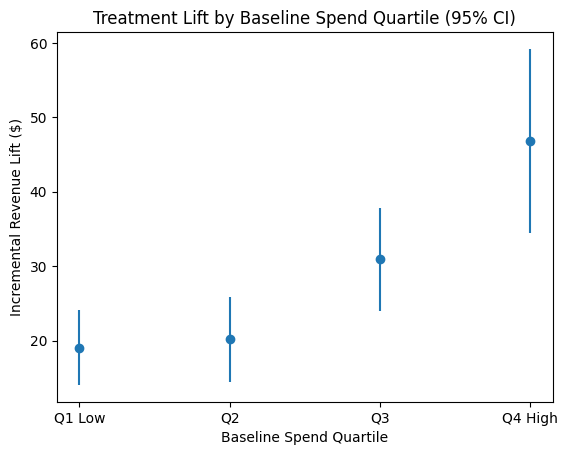

In [40]:
import matplotlib.pyplot as plt

plt.figure()

plt.errorbar(
    lift_df["baseline_quartile"],
    lift_df["lift"],
    yerr=1.96 * lift_df["se_lift"],
    fmt='o'
)

plt.title("Treatment Lift by Baseline Spend Quartile (95% CI)")
plt.xlabel("Baseline Spend Quartile")
plt.ylabel("Incremental Revenue Lift ($)")

plt.show()

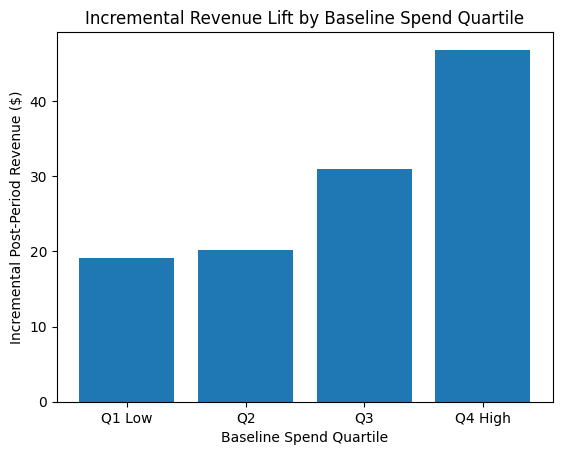

In [41]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(hte_summary["baseline_quartile"], hte_summary["lift"])
plt.title("Incremental Revenue Lift by Baseline Spend Quartile")
plt.ylabel("Incremental Post-Period Revenue ($)")
plt.xlabel("Baseline Spend Quartile")
plt.show()

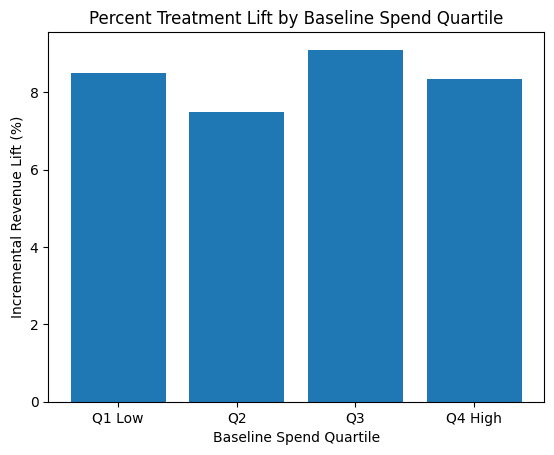

In [42]:
plt.figure()
plt.bar(hte_summary["baseline_quartile"], hte_summary["pct_lift"])
plt.title("Percent Treatment Lift by Baseline Spend Quartile")
plt.ylabel("Incremental Revenue Lift (%)")
plt.xlabel("Baseline Spend Quartile")
plt.show()

### Interpretation: 

Treatment lift is positive across all baseline spend quartiles. 

While higher-spend users exhibit larger absolute revenue gains, percentage lift is relatively similar across segments. 

This suggests that higher baseline spend translates into larger dollar impact, but baseline revenue alone may not be sufficient to justify a targeted discounting strategy.

## 9. Machine Learning Heterogeneous Treatment Effects (Causal Forest)

We complement the quartile-based segmentation with a causal forest model, which provides an exploratory, model-based view of heterogeneous treatment effects across users.

Because earlier diagnostics reveal non-parallel pre-trends, these estimates should be interpreted as descriptive rather than strictly causal.

In [43]:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# start from panel_df directly
cf_df = panel_df.copy()

# clean pre/post flag
cf_df["pre_post_flag"] = (
    cf_df["pre_post_flag"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# build user-level features from PRE period
pre_user = (
    cf_df[cf_df["pre_post_flag"] == "pre"]
    .groupby("user_id")
    .agg(
        baseline_revenue=("revenue_sim", "mean"),
        pre_rev_std=("revenue_sim", "std"),
        pre_weeks=("revenue_sim", "count"),
        treatment_flag=("treatment_flag", "max")
    )
    .reset_index()
)

# fill std if user has only one pre obs
pre_user["pre_rev_std"] = pre_user["pre_rev_std"].fillna(0)

# build user-level outcome from POST period
post_user = (
    cf_df[cf_df["pre_post_flag"] == "post"]
    .groupby("user_id")
    .agg(
        post_revenue=("revenue_sim", "mean")
    )
    .reset_index()
)

# merge to final CF dataset
user_cf = pre_user.merge(post_user, on="user_id", how="inner").copy()

# final cleanup
user_cf = user_cf.dropna().copy()

print("user_cf shape:", user_cf.shape)
print(user_cf.head())

user_cf shape: (55102, 6)
   user_id  baseline_revenue  pre_rev_std  pre_weeks  treatment_flag  \
0        2         76.045000     6.177499          4               1   
1       10        167.780000   181.429458          2               1   
2       11         96.266667    11.113061          3               0   
3       17         79.840000    26.759060          6               0   
4       19        214.350000   112.561985          3               0   

   post_revenue  
0    106.117200  
1    220.863600  
2     64.010000  
3     54.621667  
4    110.715000  


In [44]:
Y = user_cf["post_revenue"].to_numpy()
T = user_cf["treatment_flag"].to_numpy()

X = user_cf[["baseline_revenue", "pre_rev_std", "pre_weeks"]].to_numpy()

print("Y shape:", Y.shape)
print("T shape:", T.shape)
print("X shape:", X.shape)
print("Any NaN in X?", np.isnan(X).any())
print("Any NaN in Y?", np.isnan(Y).any())
print("Treatment counts:\n", user_cf["treatment_flag"].value_counts())

Y shape: (55102,)
T shape: (55102,)
X shape: (55102, 3)
Any NaN in X? False
Any NaN in Y? False
Treatment counts:
 treatment_flag
0    27605
1    27497
Name: count, dtype: int64


In [45]:
cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, min_samples_leaf=10, random_state=42),
    model_t=RandomForestRegressor(n_estimators=100, min_samples_leaf=10, random_state=42),
    n_estimators=200,
    min_samples_leaf=10,
    random_state=42
)

cf.fit(Y, T, X=X)

In [46]:
user_cf["te_pred"] = cf.effect(X)

print(user_cf["te_pred"].describe())

count    55102.000000
mean         8.398647
std          5.569632
min        -13.726701
25%          4.673415
50%          7.922942
75%         11.691129
max         46.326341
Name: te_pred, dtype: float64


In [47]:
cf_summary_stats = user_cf["te_pred"].agg(["mean", "std", "min", "max"]).round(2)
cf_summary_stats

mean     8.40
std      5.57
min    -13.73
max     46.33
Name: te_pred, dtype: float64

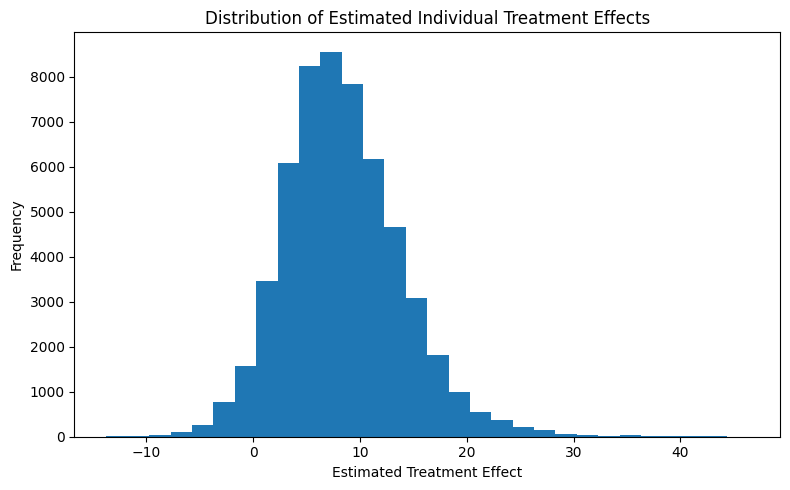

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(user_cf["te_pred"], bins=30)
plt.title("Distribution of Estimated Individual Treatment Effects")
plt.xlabel("Estimated Treatment Effect")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [49]:
user_cf["baseline_quartile"] = pd.qcut(
    user_cf["baseline_revenue"],
    4,
    labels=["Q1 Low", "Q2", "Q3", "Q4 High"]
)

cf_hte_summary = (
    user_cf.groupby("baseline_quartile")["te_pred"]
    .mean()
    .reset_index()
)

print(cf_hte_summary)

  baseline_quartile    te_pred
0            Q1 Low   5.311567
1                Q2   8.697735
2                Q3   9.275747
3           Q4 High  10.309626


### Interpretation

The causal forest estimates reveal meaningful heterogeneity in predicted treatment effects across users.

The distribution of individual treatment effects can be summarized as:

- Mean: 8.40  
- Standard deviation: 5.57  
- Min: -13.73  
- Max: 46.33  

These statistics highlight substantial variation in user response, with some users experiencing large positive effects while others exhibit little or even negative impact.

When aggregated by baseline revenue, treatment effects are somewhat higher among higher-spend users in absolute terms. However, the magnitude of this difference is modest, suggesting that baseline revenue alone is not a sufficient targeting strategy.

Because these estimates rely on model assumptions and observed covariates, they should be interpreted as exploratory evidence of potential heterogeneity rather than a validated targeting rule.

This suggests that more targeted discount strategies could improve efficiency by focusing on users with higher expected treatment effects.

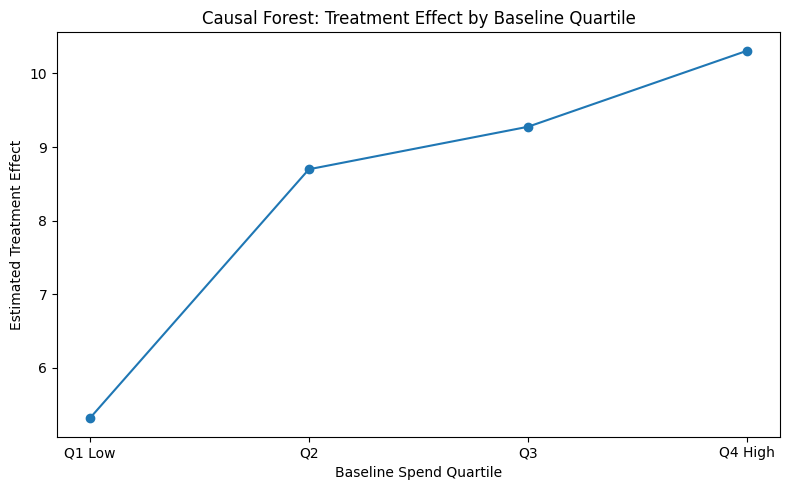

In [50]:
plt.figure(figsize=(8,5))
plt.plot(cf_hte_summary["baseline_quartile"], cf_hte_summary["te_pred"], marker='o')
plt.title("Causal Forest: Treatment Effect by Baseline Quartile")
plt.xlabel("Baseline Spend Quartile")
plt.ylabel("Estimated Treatment Effect")
plt.tight_layout()
plt.show()

In [51]:
# top 20% users by predicted treatment effect
threshold = user_cf["te_pred"].quantile(0.8)

top_users = user_cf[user_cf["te_pred"] >= threshold]
bottom_users = user_cf[user_cf["te_pred"] < threshold]

print("Top segment avg TE:", top_users["te_pred"].mean())
print("Rest avg TE:", bottom_users["te_pred"].mean())

Top segment avg TE: 16.550567024270176
Rest avg TE: 6.360528874769313


The causal forest model identifies a subset of users with substantially higher predicted treatment effects, suggesting potential gains from targeted discounting. However, because these estimates rely on model assumptions and observed covariates, a follow-up experiment is required to validate whether this targeting strategy delivers true incremental gains in practice.

In [52]:
median_rev = user_cf["baseline_revenue"].median()

user_cf["ltv_segment"] = (user_cf["baseline_revenue"] >= median_rev).astype(int)

segment_results = user_cf.groupby(["ltv_segment", "treatment_flag"])["post_revenue"].mean().unstack()

segment_results["lift"] = segment_results[1] - segment_results[0]

segment_results

treatment_flag,0,1,lift
ltv_segment,,,
0,82.217139,89.269445,7.052307
1,130.396111,139.936273,9.540162


### Interpretation
Treatment effects are slightly higher among high-LTV users in absolute terms, with an average lift of approximately $9.54 compared to $7.05 for lower-LTV users.

However, the magnitude of this difference is relatively modest, suggesting that while higher-spend users generate larger dollar gains, baseline revenue alone is not a strong driver of treatment responsiveness.

This reinforces earlier findings that simple targeting strategies based solely on historical spend may not meaningfully improve promotion efficiency.

## Business Implications

The randomized experiment suggests that the 10% discount increases post-period revenue. However, once discount cost is incorporated, the promotion does not appear profitable under a blanket rollout.

That said, the business decision depends on product context. If the promotion is intended to drive trial for a new product, acquire customers, or increase repeat purchase, a short-term loss may be strategically acceptable. Similarly, if the discount is used to clear slow-moving inventory, the promotion may still be justified by reducing holding costs or freeing inventory capacity.

From a managerial perspective, the key takeaway is that revenue lift alone is insufficient. The promotion should be evaluated against margin impact, customer lifetime value, inventory objectives, and retention effects.

## Limitations & Future Work

• Although the panel includes multiple weekly periods and an event-study specification, pre-treatment coefficients show modest differences relative to the chosen baseline period (t = -1). This suggests caution when interpreting DiD estimates, though the conclusion may be sensitive to the normalization choice.

• Revenue is simulation-based using deterministic product pricing, so real-world deployment would require validation against observed transaction revenue, discount costs, cannibalization, inventory costs, and retention effects.

• The observed pre-treatment differences may reflect imbalance in underlying user characteristics such as baseline spend. A more robust experimental design would use stratified randomization—assigning treatment within LTV or baseline-spend segments—to ensure better balance across key user groups.

• While reweighting and propensity-score methods can improve comparability on observed characteristics, they do not fully resolve differences in underlying time trends.

• I also implemented a synthetic control robustness check, which constructs a weighted control-group counterfactual that better matches treated users in the pre-treatment period. This helps evaluate whether the estimated effect is sensitive to pre-treatment trend differences.

• Future work could also expand heterogeneous treatment effect analysis using richer user features such as tenure, order frequency, category mix, and prior spending volatility.

## Business Recommendation

The randomized experiment shows a positive incremental revenue lift from the 10% discount. However, the average lift per user remains smaller than the estimated discount cost under a blanket rollout, suggesting that a broad promotion may not be profitable at scale.

The recommendation depends on strategic context. If the goal is immediate profit, the promotion should not be broadly deployed at the current 10% discount level. If the goal is product trial, customer acquisition, repeat purchase, or inventory clearance, short-term losses may be acceptable and should be evaluated against downstream outcomes.

As a result, the recommended approach is to:

- Avoid full population rollout at the current 10% discount level if the objective is short-term profitability
- Explore reduced discount levels (e.g., 5–7%) to improve margin efficiency
- Use stratified randomization in future experiments to balance key user segments before treatment assignment
- Track repeat purchase, retention, and inventory-related outcomes to capture broader strategic value
- Run follow-up experiments to test optimized targeting strategies

## Final Takeaway

The randomized A/B experiment provides a credible estimate of the promotion’s average causal impact, indicating a positive incremental revenue lift. However, the magnitude of this lift is insufficient to offset discount costs under a blanket 10% rollout.

The event study suggests some caution in interpreting panel-based DiD estimates, although the apparent pre-treatment differences may be sensitive to the chosen reference period. As a result, DiD estimates are best treated as robustness checks rather than the primary result.

Overall, the promotion may still be strategically justified in specific contexts such as product trial, customer acquisition, or inventory clearance, but it should not be evaluated on revenue lift alone. Profitability, retention, margin impact, and operational objectives should all be considered before deployment.

---

# Appendix

The appendix provides full regression outputs for all difference-in-differences specifications used in the analysis.

## A1. Clustered Difference-in-Differences Model

Focus on the interaction coefficient and its clustered standard error / 95% CI. 

Full regression output for baseline DiD specification with cluster-robust standard errors at the user level.


In [53]:
print(did_cluster.summary())

                            OLS Regression Results                            
Dep. Variable:            revenue_sim   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     431.1
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          3.31e-277
Time:                        17:44:26   Log-Likelihood:            -2.5086e+06
No. Observations:              440501   AIC:                         5.017e+06
Df Residuals:                  440497   BIC:                         5.017e+06
Df Model:                           3                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            116.5163      0.317    367.

The interaction coefficient represents the estimated incremental weekly revenue lift for treated users relative to control under the Difference-in-Differences identifying assumptions

## A2. User Fixed Effects Difference-in-Differences Model

User-level fixed effects implemented via within transformation (demeaned revenue), with cluster-robust standard errors.

In [54]:

print(fe_cluster.summary())

                            OLS Regression Results                            
Dep. Variable:       revenue_demeaned   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1057.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:44:26   Log-Likelihood:            -2.3644e+06
No. Observations:              440501   AIC:                         4.729e+06
Df Residuals:                  440498   BIC:                         4.729e+06
Df Model:                           2                                         
Covariance Type:              cluster                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.7367      0.072     38.117      

The user fixed effects specification reduces the estimated interaction effect relative to the baseline clustered DiD model, indicating that time-invariant user heterogeneity biased the naive estimate upward.

## A3. Two-Way Fixed Effects Difference-in-Differences Model

Focus on the treatment-post interaction.

This specification absorbs both user fixed effects and week fixed effects using a two-way within transformation, with cluster-robust standard errors at the user level.

In [55]:
print(twfe_model.summary())

                                 OLS Regression Results                                
Dep. Variable:            revenue_sim   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):              0.000
Method:                 Least Squares   F-statistic:                              20.22
Date:                Mon, 27 Apr 2026   Prob (F-statistic):                    6.91e-06
Time:                        17:44:26   Log-Likelihood:                     -2.3661e+06
No. Observations:              440501   AIC:                                  4.732e+06
Df Residuals:                  440500   BIC:                                  4.732e+06
Df Model:                           1                                                  
Covariance Type:              cluster                                                  
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

The two-way fixed effects estimate is materially smaller and becomes negative, reflecting sensitivity to specification and the presence of non-parallel pre-trends. This reinforces that causal interpretation should be treated cautiously and highlights the importance of the experimental design assumptions.

In [56]:
from pathlib import Path

project_root = Path.cwd().parent
output_path = project_root / "data" / "processed" / "panel_df.csv"

print(output_path)

panel_df.to_csv(output_path, index=False)

c:\Users\trist\ab-promo-incrementality\data\processed\panel_df.csv
